# Main Model & Training (Image Captioning)

## Imports & device

In [1]:
import os
import json
import pickle
import csv
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('PyTorch:', torch.__version__)
print('Device :', device)

PyTorch: 2.11.0+cu130
Device : cuda


## Config

In [2]:
IMAGE_FEATURE_DIM = 4096 
MAX_CAPTION_LEN   = 34
EMBEDDING_DIM     = 256
LSTM_UNITS        = 256
DENSE_UNITS       = 256
PAD_IDX           = 0

# === Training ===
BATCH_SIZE = 64
EPOCHS     = 10
LR         = 1e-3
DROPOUT    = 0.5
SEED       = 42
PATIENCE   = 3      # early stopping: stop if val loss doesn't improve for N epochs

# === Splits ===
# Used only as fallback if official Flickr8k split files are missing.
TRAIN_FRAC = 0.8
VAL_FRAC   = 0.1   # test = remainder (0.1)

# === Paths ===
DATA_DIR = './data'
OUT_DIR  = './outputs'
os.makedirs(OUT_DIR, exist_ok=True)

FEATURES_PATH     = os.path.join(DATA_DIR, 'features.pkl')
VOCAB_PATH        = os.path.join(DATA_DIR, 'vocab.pkl')
CAPTIONS_TXT_PATH = os.path.join(DATA_DIR, 'captions.txt')

# Official Flickr8k split files (preferred — comparable to published papers)
TRAIN_LIST_PATH = os.path.join(DATA_DIR, 'Flickr_8k.trainImages.txt')
VAL_LIST_PATH   = os.path.join(DATA_DIR, 'Flickr_8k.devImages.txt')
TEST_LIST_PATH  = os.path.join(DATA_DIR, 'Flickr_8k.testImages.txt')

MODEL_PATH = os.path.join(OUT_DIR, 'model.pt')
LOG_PATH   = os.path.join(OUT_DIR, 'training_log.csv')
PLOT_PATH  = os.path.join(OUT_DIR, 'loss_curve.png')


## Load inputs from teammates

In [3]:
import re
from collections import Counter

class Vocabulary:
    def __init__(self, freq_threshold=5):
        self.itos = {0: "<PAD>", 1: "<START>", 2: "<END>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<START>": 1, "<END>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_text(text):
        text = str(text).lower()
        text = text.replace("n't", " not")
        text = text.replace("'s", " is")
        text = text.replace("'re", " are")
        text = text.replace("-", " ")
        text = re.sub(r'[^a-z\s]', '', text)
        return text.split()

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_text(sentence):
                frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_text(text)
        return [
            self.stoi["<START>"]
        ] + [
            self.stoi.get(token, self.stoi["<UNK>"]) for token in tokenized_text
        ] + [
            self.stoi["<END>"]
        ]


In [4]:
import random
import csv as _csv

with open(FEATURES_PATH, 'rb') as f:
    image_features = pickle.load(f)
print(f'Loaded {len(image_features)} image features')
sample_id = next(iter(image_features))
print(f'Sample feature shape: {image_features[sample_id].shape}')
print(f'Sample image_id    : {sample_id}')

with open(VOCAB_PATH, 'rb') as f:
    vocab = pickle.load(f)
VOCAB_SIZE = len(vocab)
print(f'Vocab size: {VOCAB_SIZE}')


def parse_captions_file(path):
    with open(path, 'r', encoding='utf-8') as f:
        first = f.readline().strip().lower()
    is_csv = first.startswith('image,')
    out = {}
    with open(path, 'r', encoding='utf-8') as f:
        if is_csv:
            reader = _csv.reader(f)
            next(reader)  # header
            for row in reader:
                if len(row) >= 2:
                    out.setdefault(row[0].strip(), []).append(row[1].strip())
        else:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                left, cap = line.split('\t', 1)
                img = left.split('#')[0]
                out.setdefault(img, []).append(cap)
    return out

raw_captions = parse_captions_file(CAPTIONS_TXT_PATH)
print(f'Loaded raw captions for {len(raw_captions)} images')

feature_keys = set(image_features.keys())
def match_key(name):
    if name in feature_keys:
        return name
    no_ext = name.rsplit('.', 1)[0]
    if no_ext in feature_keys:
        return no_ext
    return None

captions = {}
for name, caption_list in raw_captions.items():
    key = match_key(name)
    if key is None:
        continue
    captions[key] = [np.array(vocab.numericalize(c), dtype=np.int64)
                     for c in caption_list]
print(f'Captions matched to {len(captions)} images that have features')

# === Splits: prefer official Flickr8k splits, fall back to random 80/10/10 ===
def read_split(path):
    with open(path) as f:
        return {line.strip() for line in f if line.strip()}

available = set(image_features) & set(captions)

if all(os.path.exists(p) for p in [TRAIN_LIST_PATH, VAL_LIST_PATH, TEST_LIST_PATH]):
    train_set = read_split(TRAIN_LIST_PATH)
    val_set   = read_split(VAL_LIST_PATH)
    test_set  = read_split(TEST_LIST_PATH)
    train_ids = sorted(available & train_set)
    val_ids   = sorted(available & val_set)
    test_ids  = sorted(available & test_set)
    print(f'Using OFFICIAL Flickr8k splits')
else:
    print(f'Official split files not found, falling back to random 80/10/10')
    ids = sorted(available)
    random.Random(SEED).shuffle(ids)
    n = len(ids)
    n_train = int(n * TRAIN_FRAC)
    n_val   = int(n * VAL_FRAC)
    train_ids = ids[:n_train]
    val_ids   = ids[n_train:n_train + n_val]
    test_ids  = ids[n_train + n_val:]

print(f'Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}')


Loaded 8091 image features
Sample feature shape: (4096,)
Sample image_id    : 3125628091_25a31709df.jpg
Vocab size: 2973
Loaded raw captions for 8091 images
Captions matched to 8091 images that have features
Using OFFICIAL Flickr8k splits
Train: 6000, Val: 1000, Test: 1000


## Dataset

Each caption `[<start>, w1, w2, ..., <end>]` is unrolled into many training samples:

| input image | partial caption                | target word |
|-------------|--------------------------------|-------------|
| img_feat    | `<start>`                      | w1          |
| img_feat    | `<start>, w1`                  | w2          |
| img_feat    | `<start>, w1, w2`              | w3          |
| ...         | ...                            | ...         |

We pre-compute all triples once at startup (faster than generating on the fly).

In [5]:
class CaptionDataset(Dataset):
    def __init__(self, image_ids, captions, image_features, max_len, pad_idx=0):
        self.samples = []   # list of (image_id, partial_seq, next_word)
        self.image_features = image_features
        self.max_len = max_len
        self.pad_idx = pad_idx

        for img_id in image_ids:
            if img_id not in image_features or img_id not in captions:
                continue
            for seq in captions[img_id]:
                seq = [int(t) for t in seq if int(t) != pad_idx]
                for i in range(1, len(seq)):
                    partial = seq[:i]
                    target  = seq[i]
                    # left-pad partial to max_len
                    padded = [pad_idx] * (max_len - len(partial)) + partial
                    padded = padded[-max_len:]
                    self.samples.append((img_id, np.array(padded, dtype=np.int64), target))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_id, partial, target = self.samples[idx]
        feat = torch.tensor(self.image_features[img_id], dtype=torch.float32)
        seq  = torch.tensor(partial, dtype=torch.long)
        tgt  = torch.tensor(target,  dtype=torch.long)
        return feat, seq, tgt

train_ds = CaptionDataset(train_ids, captions, image_features, MAX_CAPTION_LEN, PAD_IDX)
val_ds   = CaptionDataset(val_ids,   captions, image_features, MAX_CAPTION_LEN, PAD_IDX)
print(f'Train samples: {len(train_ds):,}')
print(f'Val   samples: {len(val_ds):,}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Train samples: 354,327
Val   samples: 59,622


## Model

```
image_input (4096,) ──> Dropout ──> Linear(256, relu) ─┐
                                                       ├── concat ──> Linear(256, relu) ──> Linear(vocab)
caption_input (34,) ──> Embedding ──> Dropout ──> LSTM(256) ──┘
```

We output **logits** (no softmax) and use `CrossEntropyLoss` which applies log-softmax internally.

In [6]:
class CaptionModel(nn.Module):
    def __init__(self, vocab_size, feat_dim=4096, emb_dim=256, lstm_units=256,
                 dense_units=256, dropout=0.5, pad_idx=0):
        super().__init__()
        # --- Image branch ---
        self.img_dropout = nn.Dropout(dropout)
        self.img_dense   = nn.Linear(feat_dim, dense_units)

        # --- Caption branch ---
        self.embedding  = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.cap_dropout = nn.Dropout(dropout)
        self.lstm       = nn.LSTM(emb_dim, lstm_units, batch_first=True)

        # --- Fusion ---
        self.fusion_dense = nn.Linear(dense_units + lstm_units, dense_units)
        self.output       = nn.Linear(dense_units, vocab_size)

    def forward(self, image_feat, caption_seq):
        # image branch
        img = self.img_dropout(image_feat)
        img = torch.relu(self.img_dense(img))                        # (B, 256)

        # caption branch
        emb = self.embedding(caption_seq)                            # (B, T, 256)
        emb = self.cap_dropout(emb)
        _, (h_n, _) = self.lstm(emb)                                 # h_n: (1, B, 256)
        cap = h_n.squeeze(0)                                         # (B, 256)

        # concatenation fusion
        fused  = torch.cat([img, cap], dim=1)                        # (B, 512)
        hidden = torch.relu(self.fusion_dense(fused))                # (B, 256)
        logits = self.output(hidden)                                 # (B, vocab)
        return logits

model = CaptionModel(
    vocab_size=VOCAB_SIZE,
    feat_dim=IMAGE_FEATURE_DIM,
    emb_dim=EMBEDDING_DIM,
    lstm_units=LSTM_UNITS,
    dense_units=DENSE_UNITS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTrainable params: {n_params:,}')


CaptionModel(
  (img_dropout): Dropout(p=0.5, inplace=False)
  (img_dense): Linear(in_features=4096, out_features=256, bias=True)
  (embedding): Embedding(2973, 256, padding_idx=0)
  (cap_dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(256, 256, batch_first=True)
  (fusion_dense): Linear(in_features=512, out_features=256, bias=True)
  (output): Linear(in_features=256, out_features=2973, bias=True)
)

Trainable params: 3,231,645


## Training loop

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for feat, seq, tgt in loader:
            feat = feat.to(device); seq = seq.to(device); tgt = tgt.to(device)
            logits = model(feat, seq)
            loss   = criterion(logits, tgt)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss    += loss.item() * feat.size(0)
            total_correct += (logits.argmax(1) == tgt).sum().item()
            total_seen    += feat.size(0)
    return total_loss / total_seen, total_correct / total_seen

history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
epochs_no_improve = 0

with open(LOG_PATH, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc'])

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)

    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss);   history['val_acc'].append(va_acc)

    with open(LOG_PATH, 'a', newline='') as f:
        csv.writer(f).writerow([epoch, tr_loss, tr_acc, va_loss, va_acc])

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
          f'val loss {va_loss:.4f} acc {va_acc:.4f}')

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        epochs_no_improve = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'vocab_size': VOCAB_SIZE,
            'max_caption_len': MAX_CAPTION_LEN,
            'image_feature_dim': IMAGE_FEATURE_DIM,
            'embedding_dim': EMBEDDING_DIM,
            'lstm_units': LSTM_UNITS,
            'dense_units': DENSE_UNITS,
            'pad_idx': PAD_IDX,
        }, MODEL_PATH)
        print(f'  ↳ saved best model (val_loss={va_loss:.4f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'  ↳ early stopping: no improvement for {PATIENCE} epochs (best val_loss={best_val_loss:.4f})')
            break


Epoch 01/10 | train loss 3.5871 acc 0.3271 | val loss 3.2936 acc 0.3557
  ↳ saved best model (val_loss=3.2936)
Epoch 02/10 | train loss 3.0493 acc 0.3655 | val loss 3.2364 acc 0.3693
  ↳ saved best model (val_loss=3.2364)
Epoch 03/10 | train loss 2.9050 acc 0.3762 | val loss 3.2608 acc 0.3730
Epoch 04/10 | train loss 2.8321 acc 0.3825 | val loss 3.2943 acc 0.3742
Epoch 05/10 | train loss 2.7870 acc 0.3860 | val loss 3.3228 acc 0.3770
  ↳ early stopping: no improvement for 3 epochs (best val_loss=3.2364)


## Plot loss curve

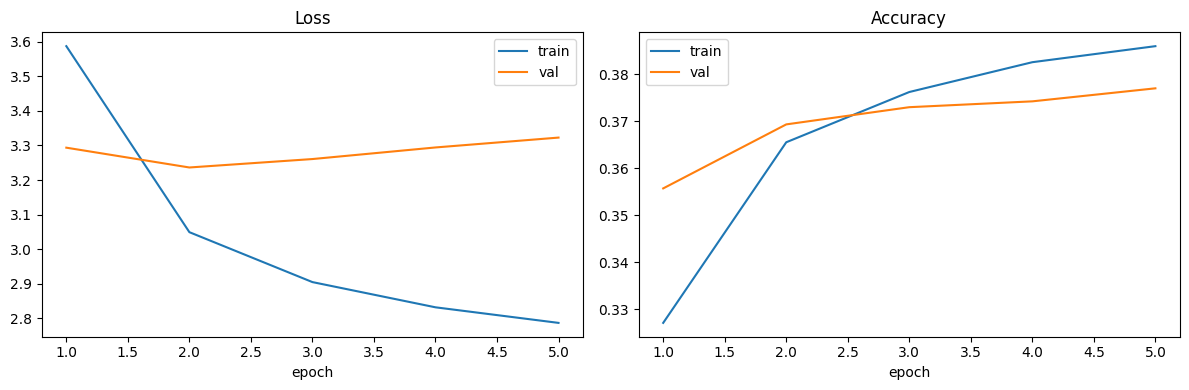

Saved plot -> ./outputs/loss_curve.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['epoch'], history['train_loss'], label='train')
axes[0].plot(history['epoch'], history['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(history['epoch'], history['train_acc'], label='train')
axes[1].plot(history['epoch'], history['val_acc'],   label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=120)
plt.show()
print(f'Saved plot -> {PLOT_PATH}')

## sanity check

Generate one caption to make sure the model works.

In [9]:
@torch.no_grad()
def quick_generate(model, vocab, feat, max_len, device):
    model.eval()
    start_id = vocab.stoi.get('<START>')
    end_id   = vocab.stoi.get('<END>')
    seq = [start_id]
    words = []
    for _ in range(max_len):
        padded = [PAD_IDX] * (max_len - len(seq)) + seq
        padded = padded[-max_len:]
        seq_t  = torch.tensor([padded], dtype=torch.long, device=device)
        feat_t = torch.tensor(feat,    dtype=torch.float32, device=device).unsqueeze(0)
        logits = model(feat_t, seq_t)
        nxt    = int(logits.argmax(1).item())
        if nxt == end_id or nxt == PAD_IDX:
            break
        seq.append(nxt)
        words.append(vocab.itos.get(nxt, ''))
    return ' '.join(words)

sample_id = train_ids[0]
print('Sample image_id:', sample_id)
print('Generated      :', quick_generate(model, vocab, image_features[sample_id],
                                         MAX_CAPTION_LEN, device))


Sample image_id: 1000268201_693b08cb0e.jpg
Generated      : a man in a red shirt and a woman in a red shirt and blue jeans is sitting on a bench
